# RAG Experiment Analysis: External Knowledge Injection for Grant Proposals

**Date**: 2026-04-22  
**Goal**: FoundOpt (01_foundopt)  
**Setup**: 3 conditions × 10 iterations, B4 (no RL), Qwen3-30B-A3B

| Condition | Retrieval | Description |
|---|---|---|
| **A** | None | Clean baseline (no RAG) |
| **B** | Pipeline | Goal keywords → OpenAlex → papers in context (100% reliable) |
| **C** | Model | LLM generates search queries → OpenAlex → papers in context |

**Core question**: Does injecting real papers into generation context improve plan quality?

In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

plt.rcParams.update({'font.size': 11, 'figure.dpi': 120, 'figure.facecolor': 'white'})

BASE = Path("../runs")
CONDITIONS = {
    "A: Baseline (no RAG)": "2026_04_21_rag_exp_A_baseline",
    "B: Pipeline RAG": "2026_04_21_rag_exp_B_pipeline",
    "C: Model RAG": "2026_04_21_rag_exp_C_model",
}
COLORS = {"A: Baseline (no RAG)": "#2196F3", "B: Pipeline RAG": "#4CAF50", "C: Model RAG": "#FF9800"}

# Load iter_summary data
data = {}
for label, run_dir in CONDITIONS.items():
    path = BASE / run_dir / "train" / "iter_summary.jsonl"
    with open(path) as f:
        data[label] = [json.loads(line) for line in f if line.strip()]
    print(f"{label}: {len(data[label])} iterations loaded")

A: Baseline (no RAG): 10 iterations loaded
B: Pipeline RAG: 10 iterations loaded
C: Model RAG: 10 iterations loaded


## 1. Training Curves: Buffer Max & Reward Mean

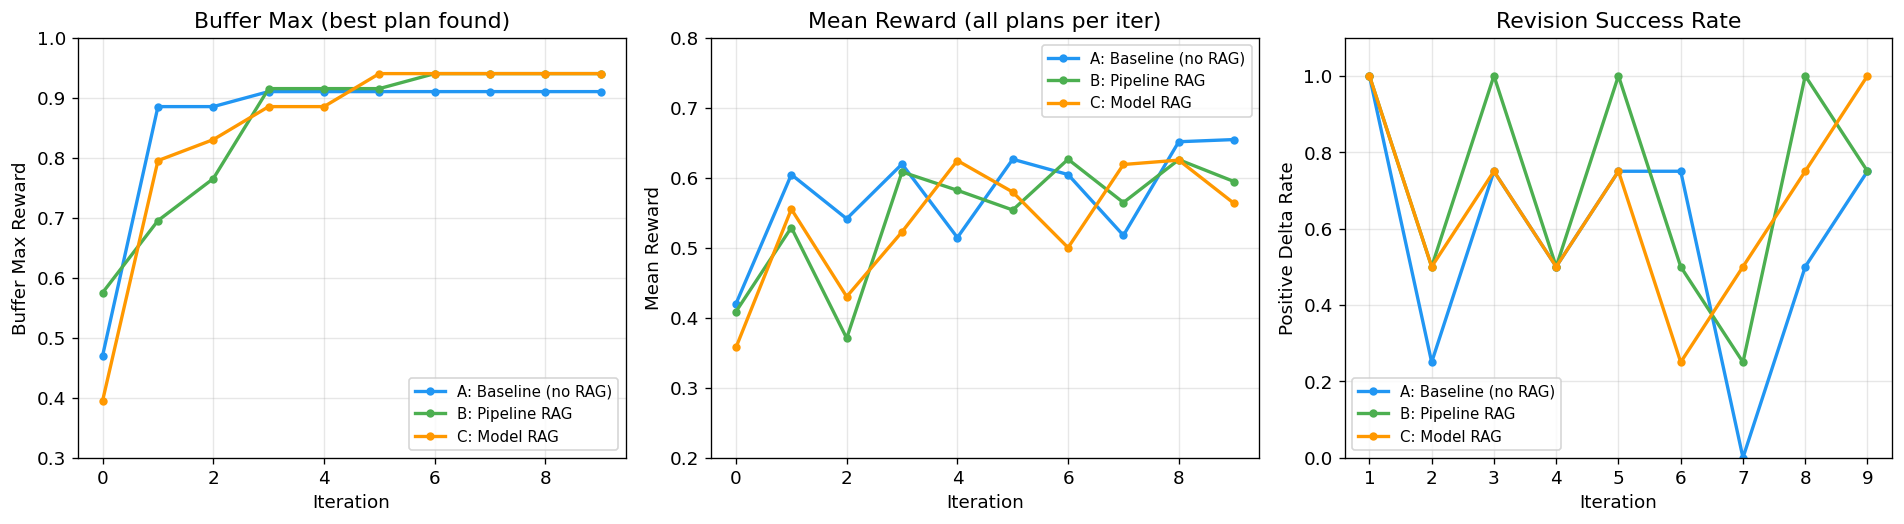

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Plot 1: Buffer Max
ax = axes[0]
for label, iters in data.items():
    x = [it["iter"] for it in iters]
    y = [it["reward/buffer_max"] for it in iters]
    ax.plot(x, y, '-o', color=COLORS[label], label=label, markersize=4, linewidth=2)
ax.set_xlabel("Iteration")
ax.set_ylabel("Buffer Max Reward")
ax.set_title("Buffer Max (best plan found)")
ax.legend(fontsize=9)
ax.set_ylim(0.3, 1.0)
ax.grid(True, alpha=0.3)

# Plot 2: Reward Mean
ax = axes[1]
for label, iters in data.items():
    x = [it["iter"] for it in iters]
    y = [it["reward/mean"] for it in iters]
    ax.plot(x, y, '-o', color=COLORS[label], label=label, markersize=4, linewidth=2)
ax.set_xlabel("Iteration")
ax.set_ylabel("Mean Reward")
ax.set_title("Mean Reward (all plans per iter)")
ax.legend(fontsize=9)
ax.set_ylim(0.2, 0.8)
ax.grid(True, alpha=0.3)

# Plot 3: Revision positive rate
ax = axes[2]
for label, iters in data.items():
    x = [it["iter"] for it in iters if it["revise/count"] > 0]
    y = [it["revise/n_positive"] / it["revise/count"] for it in iters if it["revise/count"] > 0]
    ax.plot(x, y, '-o', color=COLORS[label], label=label, markersize=4, linewidth=2)
ax.set_xlabel("Iteration")
ax.set_ylabel("Positive Delta Rate")
ax.set_title("Revision Success Rate")
ax.legend(fontsize=9)
ax.set_ylim(0, 1.1)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../analysis/rag_exp_training_curves.png", bbox_inches='tight')
plt.show()

## 2. Per-Signal Comparison (Key Signals)

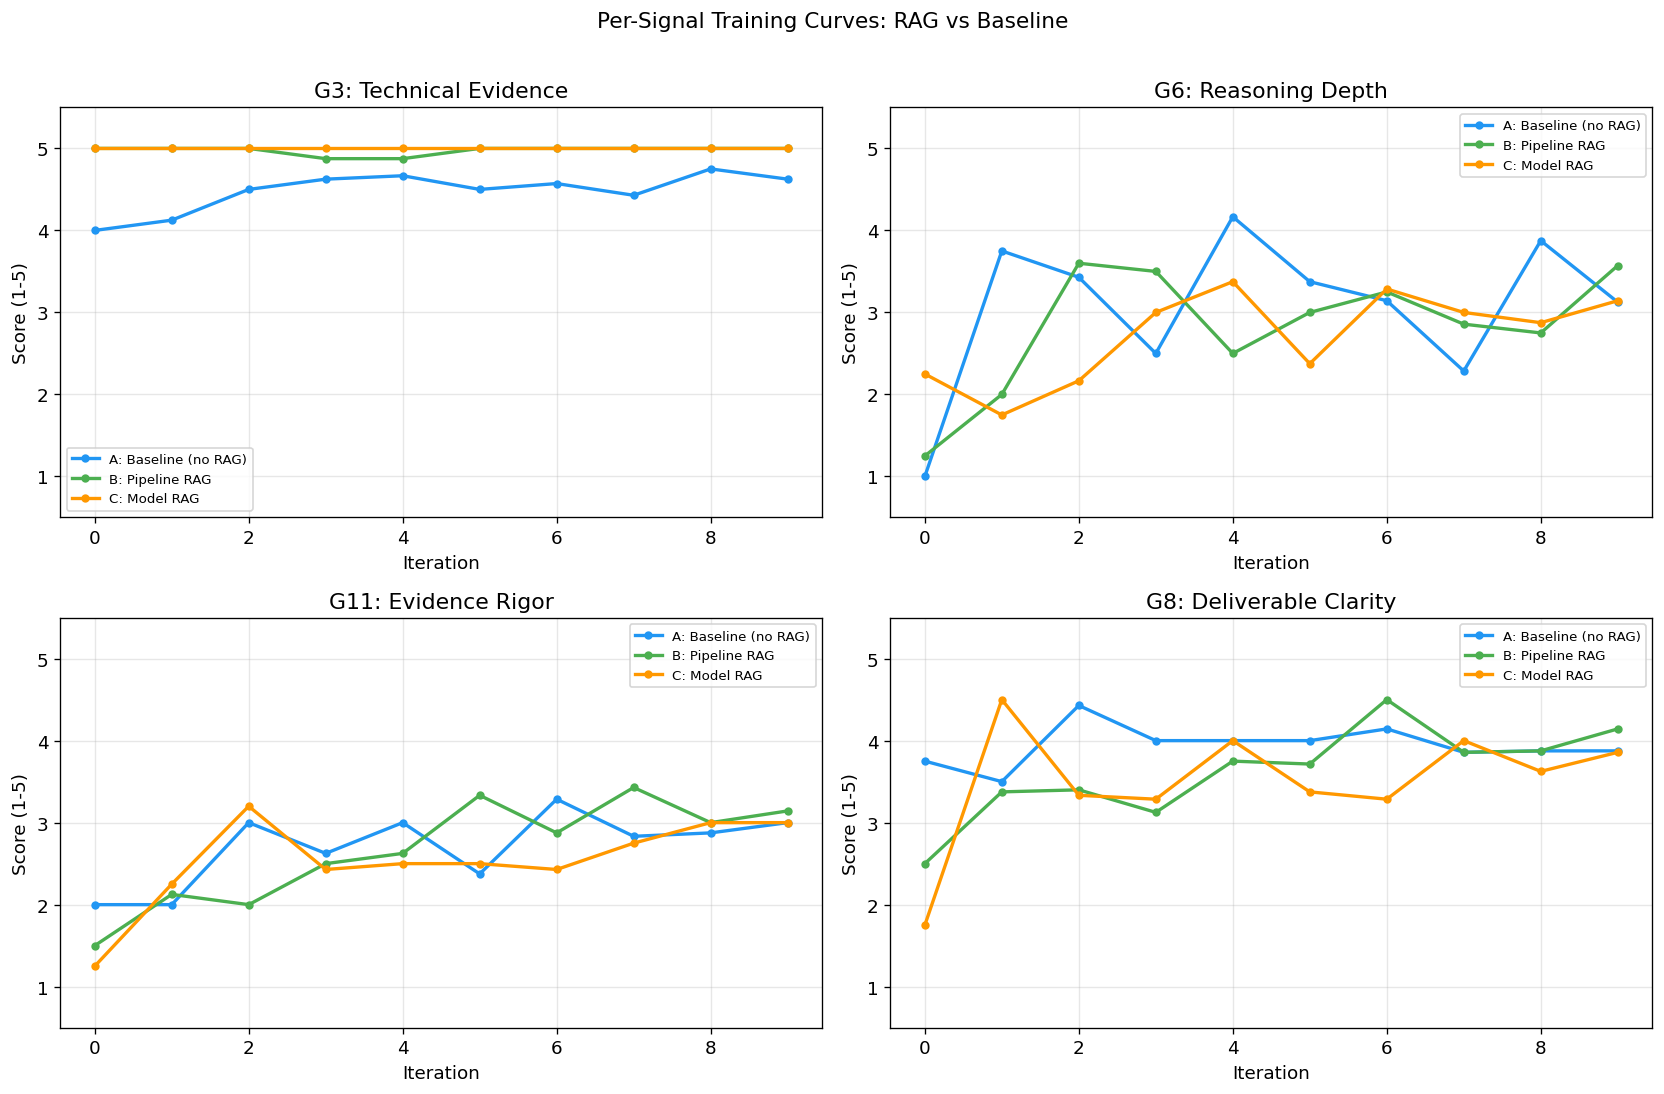

In [3]:
key_signals = [
    ("G3_technical_evidence", "G3: Technical Evidence"),
    ("G6_reasoning_depth", "G6: Reasoning Depth"),
    ("G11_evidence_rigor", "G11: Evidence Rigor"),
    ("G8_deliverable_clarity", "G8: Deliverable Clarity"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for idx, (signal_id, signal_name) in enumerate(key_signals):
    ax = axes[idx // 2][idx % 2]
    key = f"signal/{signal_id}/mean"
    for label, iters in data.items():
        x = [it["iter"] for it in iters]
        y = [it.get(key, 0) for it in iters]
        ax.plot(x, y, '-o', color=COLORS[label], label=label, markersize=4, linewidth=2)
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Score (1-5)")
    ax.set_title(signal_name)
    ax.legend(fontsize=8)
    ax.set_ylim(0.5, 5.5)
    ax.grid(True, alpha=0.3)

plt.suptitle("Per-Signal Training Curves: RAG vs Baseline", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("../analysis/rag_exp_signal_curves.png", bbox_inches='tight')
plt.show()

## 3. Citation Match Rate & Buffer Analysis

Condition                 Entries  BufMax  G3(fresh)  G6(fresh)  G8(fresh)   CitMatch
--------------------------------------------------------------------------------
A: Baseline (no RAG)           76   0.910       4.05       2.24       3.27        N/A
B: Pipeline RAG                76   0.940       4.94       1.92       2.67      23.2%
C: Model RAG                   76   0.940       5.00       2.05       2.50      25.4%


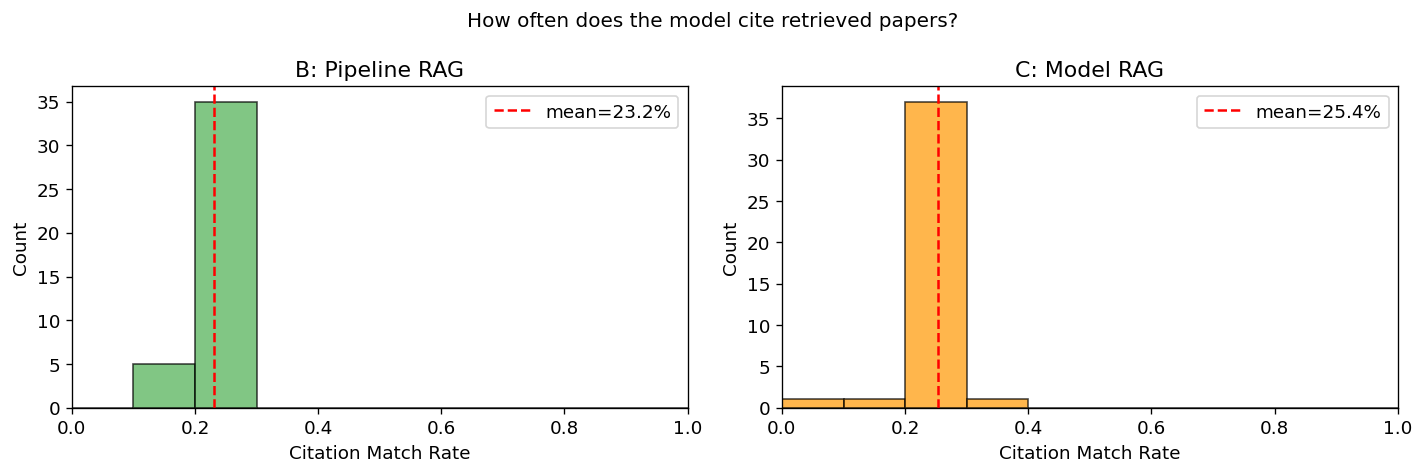

In [4]:
# Load buffer data for detailed analysis
buffers = {}
for label, run_dir in CONDITIONS.items():
    buf_path = BASE / run_dir / "buffer.jsonl"
    with open(buf_path) as f:
        buffers[label] = [json.loads(line) for line in f if line.strip()]

# Summary table
print(f"{'Condition':<25s} {'Entries':>7s} {'BufMax':>7s} {'G3(fresh)':>10s} {'G6(fresh)':>10s} {'G8(fresh)':>10s} {'CitMatch':>10s}")
print("-" * 80)
for label, buf in buffers.items():
    fresh = [e for e in buf if e.get("entry_type") == "fresh"]
    buf_max = max(e["aggregate_reward"] for e in buf)
    g3 = np.mean([e["signal_vector"]["G3_technical_evidence"] for e in fresh if e["signal_vector"].get("G3_technical_evidence")])
    g6 = np.mean([e["signal_vector"]["G6_reasoning_depth"] for e in fresh if e["signal_vector"].get("G6_reasoning_depth")])
    g8 = np.mean([e["signal_vector"]["G8_deliverable_clarity"] for e in fresh if e["signal_vector"].get("G8_deliverable_clarity")])
    cm_vals = [e["citation_match"] for e in buf if e.get("citation_match") is not None]
    cm = f"{np.mean(cm_vals):.1%}" if cm_vals else "N/A"
    print(f"{label:<25s} {len(buf):>7d} {buf_max:>7.3f} {g3:>10.2f} {g6:>10.2f} {g8:>10.2f} {cm:>10s}")

# Citation match distribution for B and C
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for idx, label in enumerate(["B: Pipeline RAG", "C: Model RAG"]):
    ax = axes[idx]
    cm_vals = [e["citation_match"] for e in buffers[label] if e.get("citation_match") is not None]
    if cm_vals:
        ax.hist(cm_vals, bins=np.arange(0, 1.05, 0.1), color=COLORS[label], alpha=0.7, edgecolor='black')
        ax.axvline(np.mean(cm_vals), color='red', linestyle='--', label=f"mean={np.mean(cm_vals):.1%}")
        ax.set_xlabel("Citation Match Rate")
        ax.set_ylabel("Count")
        ax.set_title(f"{label}")
        ax.legend()
        ax.set_xlim(0, 1)
plt.suptitle("How often does the model cite retrieved papers?", fontsize=12)
plt.tight_layout()
plt.savefig("../analysis/rag_exp_citation_match.png", bbox_inches='tight')
plt.show()

## 4. Opus Eval Comparison

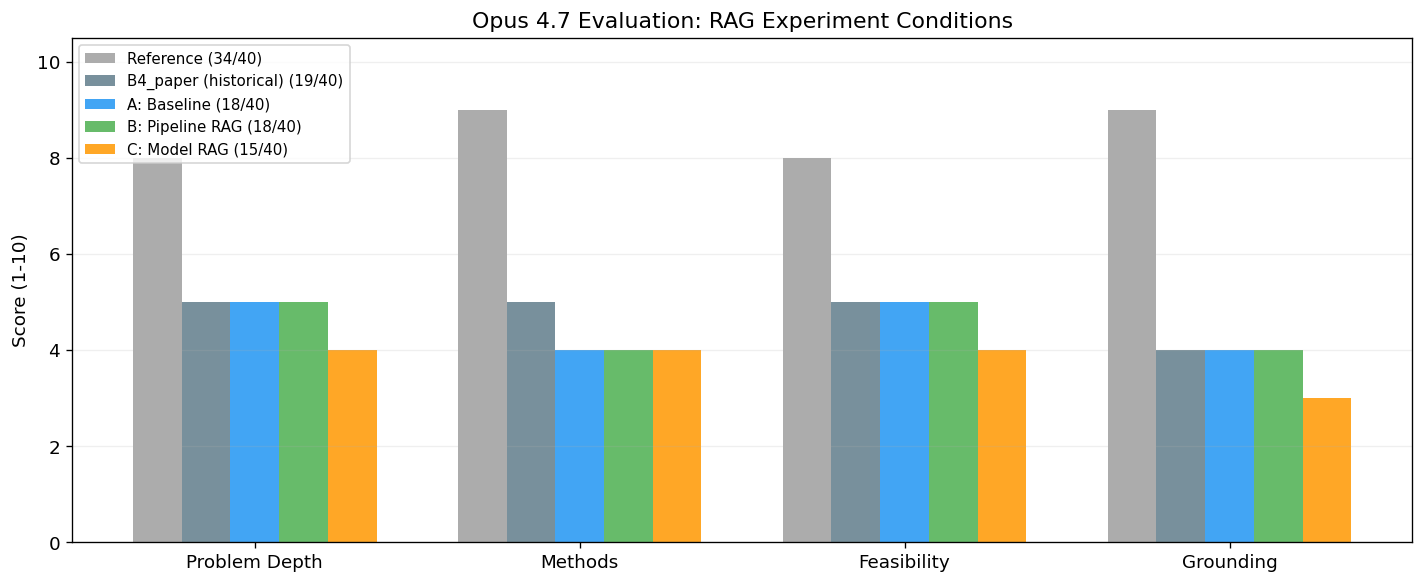

In [5]:
opus_scores = {
    "Reference":             {"depth": 8, "methods": 9, "feasibility": 8, "grounding": 9},
    "B4_paper (historical)": {"depth": 5, "methods": 5, "feasibility": 5, "grounding": 4},
    "A: Baseline":           {"depth": 5, "methods": 4, "feasibility": 5, "grounding": 4},
    "B: Pipeline RAG":       {"depth": 5, "methods": 4, "feasibility": 5, "grounding": 4},
    "C: Model RAG":          {"depth": 4, "methods": 4, "feasibility": 4, "grounding": 3},
}

dims = ["depth", "methods", "feasibility", "grounding"]
labels = list(opus_scores.keys())
x = np.arange(len(dims))
width = 0.15
bar_colors = ["#9E9E9E", "#607D8B", "#2196F3", "#4CAF50", "#FF9800"]

fig, ax = plt.subplots(figsize=(12, 5))
for i, (label, scores) in enumerate(opus_scores.items()):
    vals = [scores[d] for d in dims]
    total = sum(vals)
    ax.bar(x + i * width, vals, width, label=f"{label} ({total}/40)", color=bar_colors[i], alpha=0.85)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(["Problem Depth", "Methods", "Feasibility", "Grounding"])
ax.set_ylabel("Score (1-10)")
ax.set_title("Opus 4.7 Evaluation: RAG Experiment Conditions")
ax.legend(fontsize=9, loc="upper left")
ax.set_ylim(0, 10.5)
ax.grid(True, alpha=0.2, axis='y')
plt.tight_layout()
plt.savefig("../analysis/rag_exp_opus_eval.png", bbox_inches='tight')
plt.show()

## 5. Key Findings

**Qwen-level signals**:
- G3 Technical Evidence: **RAG +0.9** (4.05 → 4.94/5.00) — RAG successfully injects citation opportunities
- G6 Reasoning Depth: RAG **-0.3** (2.24 → 1.92) — papers consume context, reduce reasoning space
- G8 Deliverables: RAG **-0.7** (3.27 → 2.50) — same token budget trade-off
- Buffer max: B/C (0.940) slightly > A (0.910) — but within noise

**Opus eval (expert judge)**:
- A baseline: 18/40, B pipeline: 18/40, C model: 15/40
- **RAG does not improve Opus grounding** (all conditions: 3-4/10)
- Historical B4_paper (no RAG) was 19/40 — none of these beat it

**Citation match rate**: 23-25% — model uses ~1/4 of retrieved papers. Most are ignored.

**Diagnosis**: The bottleneck is not knowledge availability but **knowledge integration capability** at 30B scale. The model sees real papers but cannot deeply integrate them into its reasoning. This confirms that the quality gap requires either (1) a larger model (235B showed grounding 6/10) or (2) training the model specifically to integrate external evidence.